<a href="https://colab.research.google.com/github/JustynaGoc/machine-learning-bootcamp/blob/main/Supervised/03_linear_regression_r2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresja  Liniowa  r2


## Import bibliotek

In [86]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True, edgeitems=30, linewidth=120,
                    formatter=dict(float=lambda x: f'{x:.2f}'))
sns.set(font_scale=1.3)
sklearn.__version__

'1.6.1'

## Wygenerowanie danych

In [87]:
from sklearn.datasets import make_regression

data, target = make_regression(n_samples=100, n_features=1, n_targets=1, noise=30.0, random_state=42)

print(f'data shape: {data.shape}')
print(f'target shape: {target.shape}')

data shape: (100, 1)
target shape: (100,)


In [88]:
data[:5]

array([[0.93],
       [0.09],
       [-1.06],
       [0.31],
       [-0.48]])

In [89]:
target[:5]

array([74.59, -37.46, -16.46, 5.35, -13.21])

## Wykres danych

/tmp/ipykernel_30725/2006125307.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


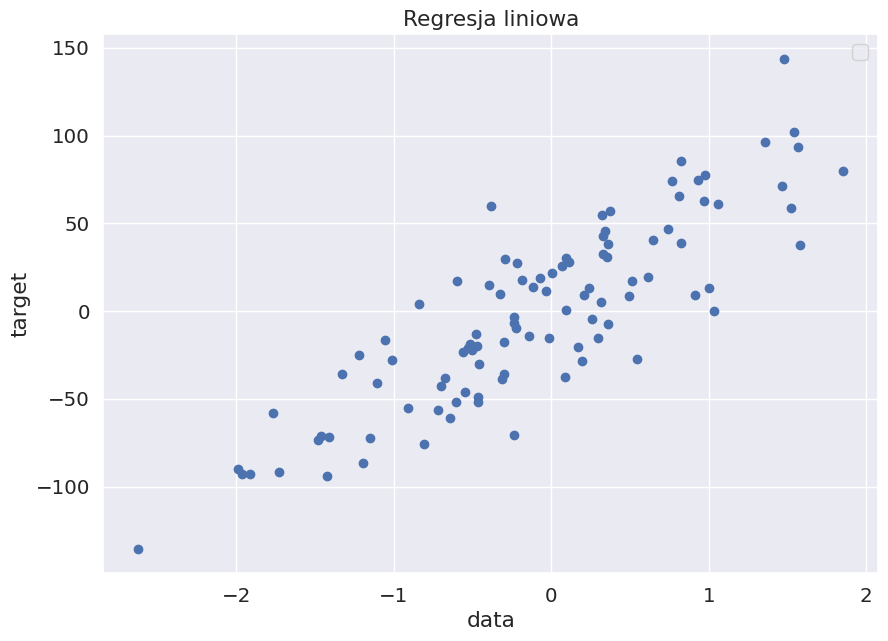

In [90]:
plt.figure(figsize=(10,7))
plt.title('Regresja liniowa')
plt.ylabel('target')
plt.xlabel('data')
plt.scatter(data, target)
plt.legend()
plt.show()

## Regresja liniowa  przy uzyciu Scikit- learn


In [91]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(data, target)

LinearRegression()

In [92]:
#r2 score
regressor.score(data, target)

0.7426670084336404

In [93]:
y_pred = regressor.predict(data)
y_pred

array([49.90, 7.83, -49.21, 19.15, -20.38, 35.77, -19.60, 30.53, 33.97, 53.50, 44.45, 80.13, 40.29, -7.45, -36.79,
       8.07, -94.15, 29.07, 54.87, -127.04, 28.25, 8.33, -19.71, 49.11, 81.46, 76.53, -26.43, 1.71, -26.49, -56.11,
       21.29, 22.22, 16.50, -22.90, -41.75, 13.30, -11.40, 21.52, 44.48, -11.04, 21.50, -30.24, 79.39, -22.33, -8.17,
       -16.04, -11.51, -28.65, 19.88, 13.90, -12.83, 3.75, -8.17, 77.14, -15.69, 20.62, 20.00, -5.76, -8.19, -95.54,
       19.64, -7.75, -51.63, -31.49, -69.43, 51.76, -82.46, -91.84, -24.52, 41.74, 43.98, -66.88, -70.18, -57.34,
       -38.32, 82.19, 52.11, 15.55, 18.25, -23.63, -84.36, 9.02, 12.03, -62.69, 56.17, -2.27, -19.90, 2.82, -46.97,
       -3.39, -53.86, 71.08, 6.86, -21.51, -19.46, 95.79, -67.50, -32.37, -0.09, -11.91])

## Wizualizacja graficzna modelu

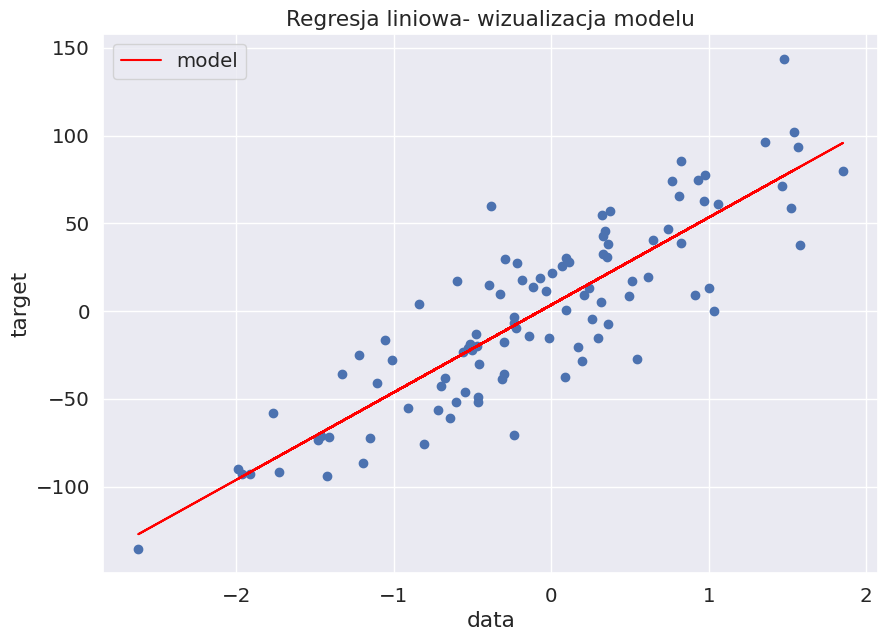

In [94]:
plt.figure(figsize=(10,7))
plt.title('Regresja liniowa- wizualizacja modelu')
plt.ylabel('target')
plt.xlabel('data')
plt.scatter(data, target)
plt.plot(data, y_pred, color='red', label = 'model')
plt.legend()
plt.show()

## Współczynnik R2

In [95]:
# wzor R2
# u = ((y_true - y_pred )**2).sum()
# v = ((y_true - y_true.mean())**2).sum()
# r2 = 1 - u/v
# r2

In [96]:
u = ((target - y_pred )**2).sum()
v = ((target - target.mean())**2).sum()
r2 = 1 - u/v
r2

np.float64(0.7426670084336404)

In [97]:
r2 = regressor.score(data, target)
r2

0.7426670084336404

In [98]:
## wyswietlenie  listy dostepnych opcji

In [99]:
[item  for item in dir(regressor) if not   item.startswith('_')]

['coef_',
 'copy_X',
 'fit',
 'fit_intercept',
 'get_metadata_routing',
 'get_params',
 'intercept_',
 'n_features_in_',
 'n_jobs',
 'positive',
 'predict',
 'rank_',
 'score',
 'set_fit_request',
 'set_params',
 'set_score_request',
 'singular_']

In [100]:
regressor.coef_

array([49.83])

In [101]:
regressor.intercept_

np.float64(3.4953459615809184)

## Końcowa postawc modelu

In [102]:
# Y = w0 + w1*X1
# Y = 3,495 + 49.83*X1

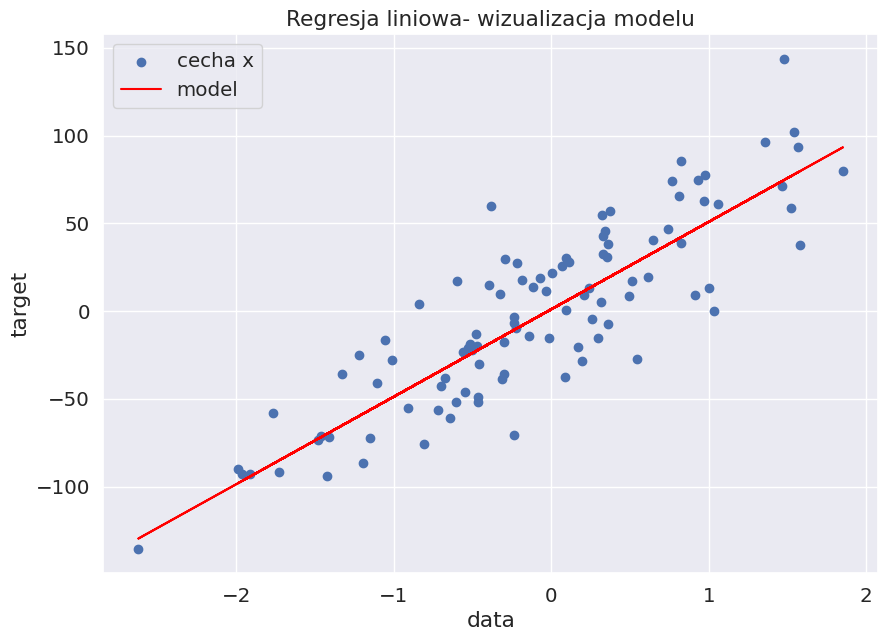

In [103]:
plt.figure(figsize=(10,7))
plt.title('Regresja liniowa- wizualizacja modelu')
plt.ylabel('target')
plt.xlabel('data')
plt.scatter(data, target, label = 'cecha x')
plt.plot(data, regressor.fit_intercept + regressor.coef_[0]*data, color='red', label = 'model')
plt.legend()
plt.show()

# Regresja liniowa z podzialem na zbiór treningowy oraz testowy

## Wygenerowanie danych


In [104]:
data, target = make_regression(n_samples=1000, n_features=1, n_targets=1, noise=15.0, random_state=42)

print(f'data shape: {data.shape}')
print(f'target shape: {target.shape}')

data shape: (1000, 1)
target shape: (1000,)


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.25)


print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (750, 1)
X_test shape: (250, 1)
y_train shape: (750,)
y_train shape: (750,)


## Wizualizacja danych

[]

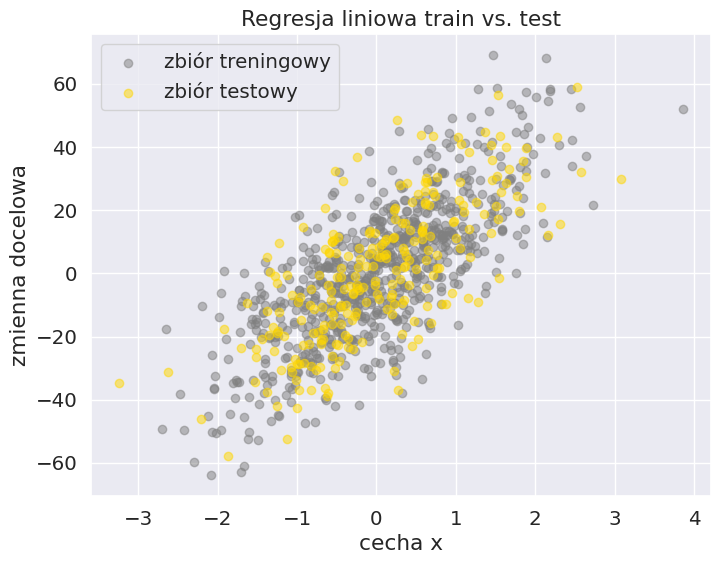

In [106]:

plt.figure(figsize=(8, 6))
plt.title('Regresja liniowa train vs. test')
plt.xlabel('cecha x')
plt.ylabel('zmienna docelowa')
plt.scatter(X_train, y_train, label='zbiór treningowy', color='gray', alpha=0.5)
plt.scatter(X_test, y_test, label='zbiór testowy', color='gold', alpha=0.5)
plt.legend()
plt.plot()

## Trenowaie modelu  na danych  treningowych

In [107]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [108]:
regressor.score(X_train, y_train)

0.5550440098049001

In [109]:
regressor.score(X_test, y_test)

0.5108438585354155

## Wizualizacja graficzna modelu

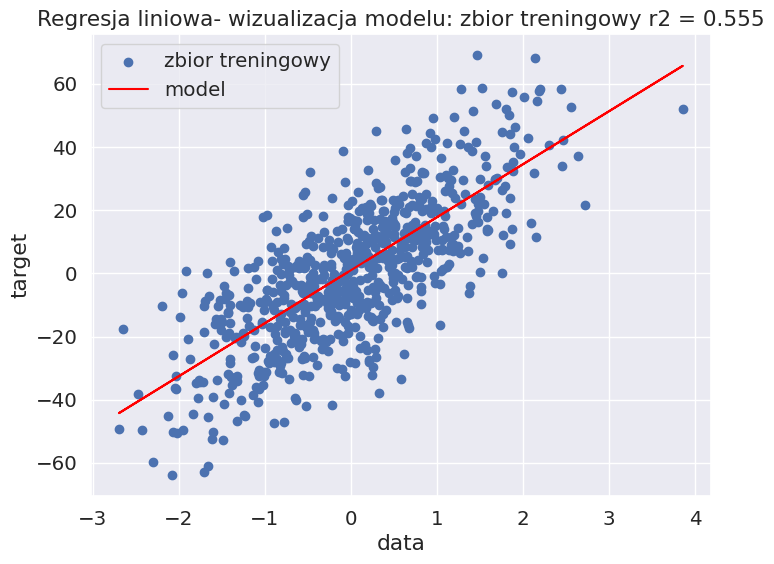

In [112]:
plt.figure(figsize=(8,6))
plt.title(f'Regresja liniowa- wizualizacja modelu: zbior treningowy r2 = {regressor.score(X_train, y_train):.3f}')
plt.ylabel('target')
plt.xlabel('data')
plt.scatter(X_train, y_train, label = 'zbior treningowy')
plt.plot(X_train, regressor.fit_intercept + regressor.coef_[0]*X_train, color='red', label = 'model')
plt.legend()
plt.show()

[]

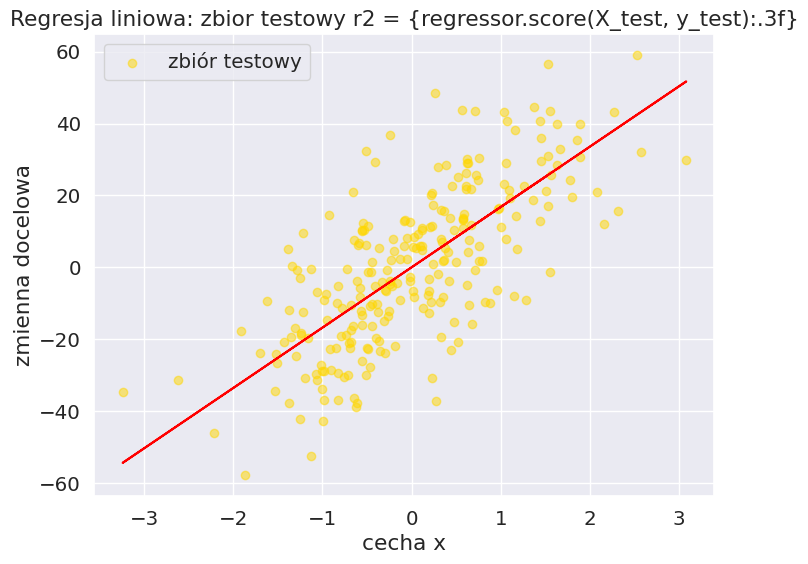

In [115]:
plt.figure(figsize=(8, 6))
plt.title('Regresja liniowa: zbior testowy r2 = {regressor.score(X_test, y_test):.3f}')
plt.xlabel('cecha x')
plt.ylabel('zmienna docelowa')
plt.scatter(X_test, y_test, label='zbiór testowy', color='gold', alpha=0.5)
plt.plot(X_test, regressor.intercept_ + regressor.coef_[0] * X_test, color='red')
plt.legend()
plt.plot()

## Predykcja  na podstawie modelu

In [119]:
y_pred = regressor.predict(X_test)
y_pred[:5]

array([25.60, 5.95, 31.62, -16.49, -10.80])

In [120]:
predictions = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
predictions.head()

,y_test,y_pred
0,30.876983,25.601338
1,1.850537,5.954600
2,30.604981,31.624589
3,-9.092543,-16.490844
4,-36.311708,-10.800495


In [123]:
predictions['error'] = predictions['y_test'] -predictions['y_pred']
predictions.head()

,y_test,y_pred,error
0,30.876983,25.601338,5.275646
1,1.850537,5.954600,-4.104063
2,30.604981,31.624589,-1.019608
3,-9.092543,-16.490844,7.398301
4,-36.311708,-10.800495,-25.511212


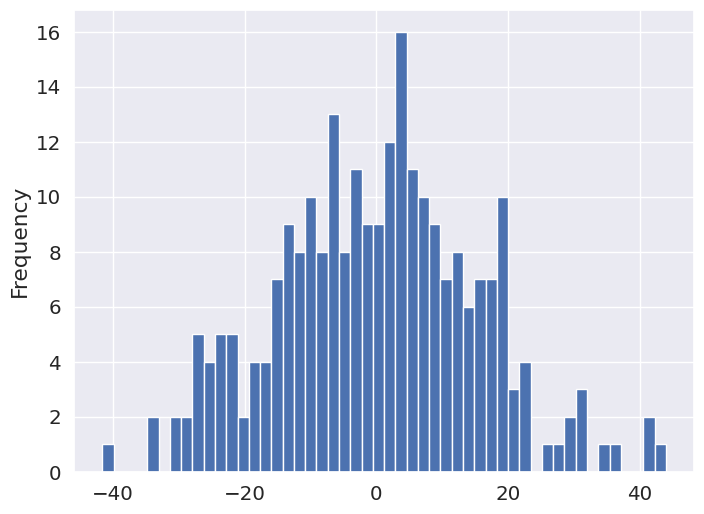

In [124]:
_ =predictions['error'].plot(kind = 'hist', bins =50, figsize =(8,6))